# Predicción de ocurrencia de infarto cerebral 

<a id="indice"></a>
# Índice del proyecto

## Tabla de contenidos

- [1. Análisis exploratorio de datos (EDA)](#eda)
  - [1.1 Análisis univariante](#analisis-univariante)
    - [Variables identificadoras y demográficas](#variables-demograficas)
    - [Variables clínicas](#variables-clinicas)
    - [Variables socioeconómicas y estilo de vida](#variables-socioeconomicas)
    - [Variable objetivo (`stroke`)](#variable-objetivo)
    - [Valores nulos](#nulos)
  - [1.2 Análisis Bivariante](#análisis-bivariante)
    - [Variables numericas](#variables-numericas)
    - [Variables categoricas](#variables-categoricas)

- [2. Limpieza y transformación de los datos](#limpieza)
---

<a id="eda"></a>
# 1. Análisis Exploratorio de Datos (EDA)

In [1]:
# importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
# lectura del csv
df = pd.read_csv ("stroke.csv")

In [3]:
# muestra de las 5 primeras filas
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# dimensiones del dataframe 
df.shape

(5110, 12)

El dataframe tiene 12 columnas con las variables de 5110 individuos. 

In [5]:
# información sobre las variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


---

<a id="analisis-univariante"></a>
## 1.1 Análisis Univariante

<a id="variables-demograficas"></a>
#### <a id="seccion-1-1-1"></a>Variables identificadoras y demográficas

<a id="variables-demograficas"></a>
* id

In [6]:
# Devuelve True si hay al menos un ID duplicado, False si todos son únicos
df["id"].duplicated().any()

np.False_

La columna id contiene valores únicos para cada paciente, por lo que no aporta valor predictivo y será eliminada en la fase de preparación de datos.

* age

In [7]:
# Resumen estadístico de la edad
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [8]:
# Redondea al entero más cercano y convierte el tipo de dato a entero (int64)
df["age"] = df["age"].round().astype(int)

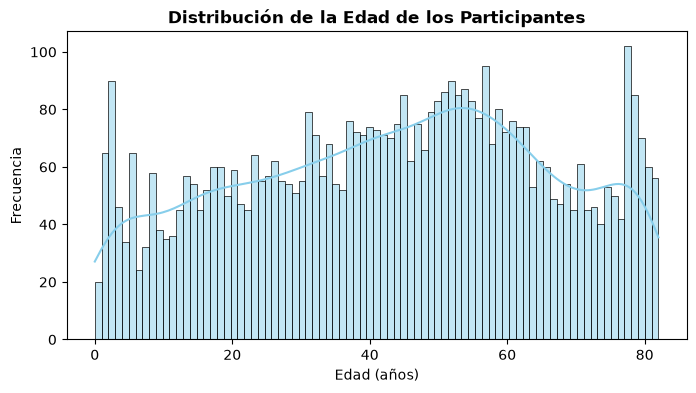

In [9]:
# gráfico para entender la distribución de la edad en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=83, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Participantes", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

In [10]:
# Contar número de personas con edad menor a 18
menores_18 = (df["age"] < 18).sum()
porcentaje_menores = (df["age"] < 18).mean() * 100

print(f"Número de menores de 18 años: {menores_18}")
print(f"Porcentaje sobre el total: {porcentaje_menores:.2f}%")

Número de menores de 18 años: 856
Porcentaje sobre el total: 16.75%


In [11]:
# Ver cuántos casos de ictus hay entre los menores de 18 años
df[df["age"] < 18]["stroke"].value_counts()

stroke
0    854
1      2
Name: count, dtype: int64

In [12]:
# 1. Crear una copia filtrada solo con adultos (18 años o más)
df_adultos = df[df["age"] >= 18].copy()

# 2. Verificar las dimensiones de ambos DataFrames
print(f"Filas en el DataFrame original (con menores): {df.shape[0]}")
print(f"Filas en el DataFrame filtrado (solo adultos): {df_adultos.shape[0]}")
print(f"Menores eliminados: {len(df) - len(df_adultos)}")

Filas en el DataFrame original (con menores): 5110
Filas en el DataFrame filtrado (solo adultos): 4254
Menores eliminados: 856


De las 856 personas menores de 18 años, únicamente 2 casos presentan registro de ictus (frente a los 247 casos en adultos). Esta baja prevalencia, sumada a la diferencia etiología del accidente cerebrovascular en pediatría, respalda la decisión metodológica de acotar el estudio a la población adulta (>18 años) para comparar los resultados con el modelo de referencia (Dritsas & Trigka, 2022).
El filtrado de pacientes menores de 18 años (age >= 18) se realiza al inicio del estudio y no en la fase de limpieza posterior para asegurar que todo el Análisis Exploratorio de Datos (EDA) responda de forma coherente al problema clínico abordado. De este modo, las métricas descriptivas, tablas de frecuencia y relaciones bivariantes se estudian desde el primer momento exclusivamente sobre la muestra representativa de adultos de riesgo.

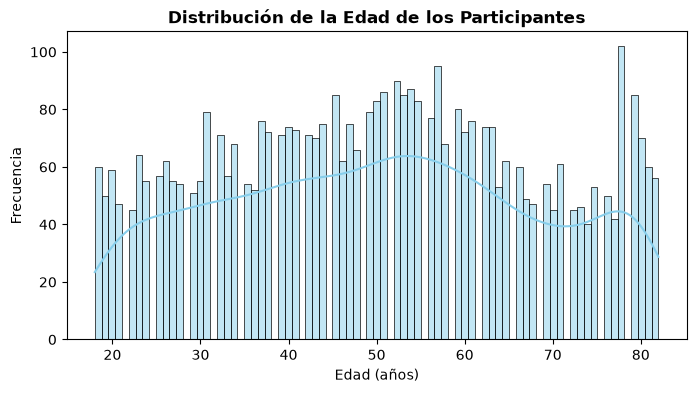

In [13]:
#gráfico para entender la distribución de la edad de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["age"], bins=83, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Participantes", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

Histograma: Distribución de la edad de los participantes adultos
Tras acotar la muestra a la población adulta, el gráfico muestra la distribución de frecuencia por cada año de edad individual (de 18 a 82 años) La muestra cubre de forma continua el espectro adulto desde los 18 hasta los 82 años.   Se observa una mayor densidad de participantes en la franja media-avanzada, concretamente entre los 50 y 60 años, donde se alcanza la cúspide de la curva de estimación de densidad. Destaca un pico pronunciado de frecuencia alrededor de los 78 y 80 años (superando los 100 registros para una sola edad). Esto sugiere un posible sesgo de redondeo o agrupación en la recogida original de datos en pacientes octogenarios.

In [14]:
# 1. Definir los cortes y etiquetas para los rangos de edad
cortes = [18, 25, 35, 45, 55, 65, 75, 83]
etiquetas = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

# 2. Crear la nueva variable de rango de edad en el DataFrame filtrado
df_adultos['age_group'] = pd.cut(df_adultos['age'], bins=cortes, labels=etiquetas, right=False)

# 3. Mostrar tabla de frecuencias absolutas y relativas
tabla_edades = pd.DataFrame({
    'Total Participantes': df_adultos['age_group'].value_counts(sort=False),
    'Porcentaje (%)': (df_adultos['age_group'].value_counts(normalize=True, sort=False) * 100).round(2),
    'Casos de Ictus': df_adultos.groupby('age_group')['stroke'].sum(),
    'Tasa Ictus (%)': (df_adultos.groupby('age_group')['stroke'].mean() * 100).round(2)
})

tabla_edades

,Total Participantes,Porcentaje (%),Casos de Ictus,Tasa Ictus (%)
age_group,,,,
18-24,380,8.93,0,0.00
25-34,609,14.32,1,0.16
35-44,688,16.17,7,1.02
45-54,798,18.76,27,3.38
55-64,752,17.68,53,7.05
65-74,509,11.97,57,11.20
75+,518,12.18,102,19.69


Agrupamiento por rangos de edad:El volumen de participantes por grupo alcanza su máximo en la franja de 45 a 54 años (18.76 %). El grupo de edad más avanzada (75+ años) representa un 12.18\% del total (518 individuos), descartando un sesgo de sobrerepresentación en octogenarios.   La tasa de incidencia de ictus muestra un crecimiento posiblemente correlacionado con la edad:   muy baja en menores de 45 años (<1%).   Se sitúa en el 7.05\% entre los 55 y 64 años.   Alcanza el 19.69\% en el grupo de 75+ años, donde prácticamente 1 de cada 5 personas ha sufrido un ictus.   Conclusión: Concentrar la mayoría de los casos positivos de ictus (102 de los 247 totales) en el grupo de mayor edad confirma la coherencia biológica y clínica del dataset para el posterior modelado predictivo.   

* gender

In [15]:
# Muestra un array con las respuestas únicas
df_adultos["gender"].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [16]:
# Frecuencias absolutas y relativas para 'gender'
frecuencias_gender = df_adultos["gender"].value_counts()
porcentajes_gender = df_adultos["gender"].value_counts(normalize=True) * 100

resumen_gender = pd.DataFrame({
    'Frecuencia': frecuencias_gender,
    'Porcentaje (%)': porcentajes_gender.round(2)
})

resumen_gender

,Frecuencia,Porcentaje (%)
gender,,
Female,2576,60.55
Male,1677,39.42
Other,1,0.02


<a id="variables-clinicas"></a>
#### <a id="seccion-1-1-2"></a>Variables Clínicas

* hypertension

In [17]:
# comprobar categorías
df_adultos["hypertension"].unique()

array([0, 1])

In [18]:

# Tabla de frecuencias absolutas y relativas
tabla_hypertension = pd.DataFrame({
    "Participantes": df_adultos["hypertension"].value_counts(),
    "Porcentaje (%)": (df_adultos["hypertension"].value_counts(normalize=True) * 100).round(2)
})

tabla_hypertension

,Participantes,Porcentaje (%)
hypertension,,
0,3757,88.32
1,497,11.68


* heart_disease

In [19]:
# valores único
df_adultos["heart_disease"].unique()

array([1, 0])

In [20]:
# tabla de frecuencias
tabla_heart_disease = pd.DataFrame({
    "Participantes adultos": df_adultos["heart_disease"].value_counts(),
    "Porcentaje (%)": (df_adultos["heart_disease"].value_counts(normalize=True) * 100).round(2)
})

tabla_heart_disease

,Participantes adultos,Porcentaje (%)
heart_disease,,
0,3979,93.54
1,275,6.46


* avg_glucose_level

In [21]:
df_adultos["avg_glucose_level"] = df_adultos["avg_glucose_level"].round()

In [22]:
df_adultos["avg_glucose_level"].describe()

count    4254.000000
mean      108.511519
std        47.777895
min        55.000000
25%        77.000000
50%        92.000000
75%       116.000000
max       272.000000
Name: avg_glucose_level, dtype: float64

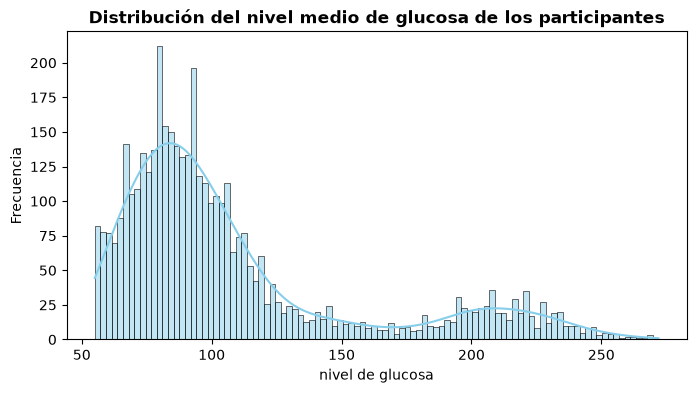

In [23]:
#gráfico para entender la distribución de los valores medios de glucosa de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["avg_glucose_level"], bins=100, kde=True, color="skyblue")
plt.title("Distribución del nivel medio de glucosa de los participantes", fontsize=12, fontweight="bold")
plt.xlabel("nivel de glucosa", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

La distribución del nivel medio de glucosa presenta una mayor concentración de participantes en valores aproximadamente comprendidos entre 70 y 110. También se observa un segundo grupo de valores elevados, situado aproximadamente entre 180 y 230, además de algunos valores extremos cercanos a 270. Esta distribución bimodal podría reflejar la coexistencia de participantes con niveles habituales de glucosa y otros con valores elevados, por lo que la variable no parece seguir una distribución normal.

* bmi

In [24]:
df_adultos["bmi"].describe()

count    4073.000000
mean       30.432752
std         7.235143
min        11.300000
25%        25.400000
50%        29.200000
75%        34.200000
max        92.000000
Name: bmi, dtype: float64

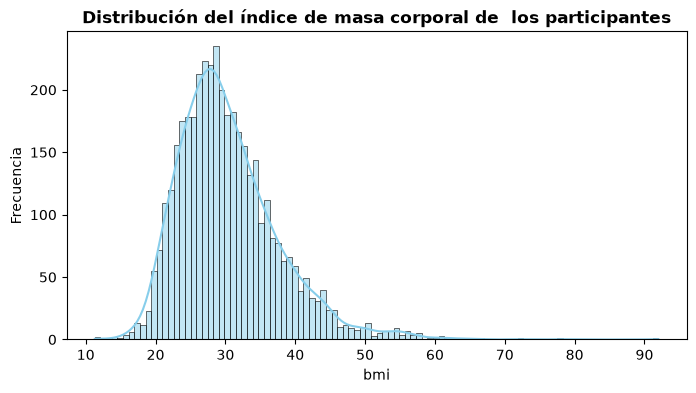

In [25]:
#gráfico para entender la distribución del indice de masa corporal de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["bmi"], bins=100, kde=True, color="skyblue")
plt.title("Distribución del índice de masa corporal de  los participantes", fontsize=12, fontweight="bold")
plt.xlabel("bmi", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

La variable bmi (Índice de Masa Corporal) muestra una distribución unimodal con una marcada asimetría positiva (sesgada a la derecha), concentrando la mayor densidad de participantes en el rango de 25 a 35 $\text{kg/m}^2$. (pico principal del histograma). Aunque la mayor parte de la muestra se sitúa en valores normopeso y sobrepeso/obesidad moderada, se observa una cola derecha bastante extendida que alcanza valores extremos por encima de 50 e incluso superando los 90 $\text{kg/m}^2$. Esta presencia de valores atípicos (outliers) acentuados sugiere la necesidad de evaluar su tratamiento o posible imputación mediante métricas robustas a la asimetría (como la mediana) antes del modelado predictivo.

In [26]:
# Presencia de valores nulos
n_nulos_bmi = df_adultos["bmi"].isna().sum()
pct_nulos_bmi = df_adultos["bmi"].isna().mean() * 100

print(f"Valores nulos en BMI: {n_nulos_bmi}")
print(f"Porcentaje de valores nulos en BMI: {pct_nulos_bmi:.2f}%")

Valores nulos en BMI: 181
Porcentaje de valores nulos en BMI: 4.25%


La variable índice de masa corporal (bmi) presentó 181 valores ausentes (4,3 % de la muestra adulta). Las estadísticas descriptivas y la representación gráfica de BMI se calcularon con los valores observados. La gestión de los valores faltantes se realizó posteriormente durante la fase de preprocesamiento del modelo.

<a id="variables-socioeconomicas"></a>
#### <a id="seccion-1-1-3"></a>Variables Socioeconómicas y Estilo de Vida

* smoking_status

In [27]:
df_adultos["smoking_status"].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [28]:
#tabla de frecuencias
tabla_smoking_status = pd.DataFrame({
    "Participantes adultos": df_adultos["smoking_status"].value_counts(),
    "Porcentaje (%)": (df_adultos["smoking_status"].value_counts(normalize=True) * 100).round(2)
})

tabla_smoking_status

,Participantes adultos,Porcentaje (%)
smoking_status,,
never smoked,1752,41.18
Unknown,862,20.26
formerly smoked,860,20.22
smokes,780,18.34


* ever_married

In [29]:
df_adultos["ever_married"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [30]:
# Mapeo directo de Yes/No a 1/0
df_adultos["ever_married"] = df_adultos["ever_married"].map({"Yes": 1, "No": 0})

In [31]:
#tabla de frecuencias
tabla_ever_married = pd.DataFrame({
    "Participantes adultos": df_adultos["ever_married"].value_counts(),
    "Porcentaje (%)": (df_adultos["ever_married"].value_counts(normalize=True) * 100).round(2)
})

tabla_ever_married

,Participantes adultos,Porcentaje (%)
ever_married,,
1,3353,78.82
0,901,21.18


* work_type

In [32]:
# comprobamos que en el dataset original no hay adultos clasificados como "children" 
n_children = (df["work_type"] == "children").sum()
n_children_mayores_18 = ((df["work_type"] == "children") & (df["age"] >= 18)).sum()

print(f"Participantes clasificados como 'children': {n_children}")
print(f"Participantes 'children' con edad >= 18 años: {n_children_mayores_18}")
print(f"Edad máxima en la categoría 'children': {df.loc[df['work_type'] == 'children', 'age'].max()}")

Participantes clasificados como 'children': 687
Participantes 'children' con edad >= 18 años: 0
Edad máxima en la categoría 'children': 16


In [33]:
#comprobamos que en el dataset de adultos no hay categoría "children"
df_adultos["work_type"].unique()

<StringArray>
['Private', 'Self-employed', 'Govt_job', 'Never_worked']
Length: 4, dtype: str

In [34]:
#tabla de frecuencias
tabla_work_type = pd.DataFrame({
    "Participantes adultos": df_adultos["work_type"].value_counts(),
    "Porcentaje (%)": (df_adultos["work_type"].value_counts(normalize=True) * 100).round(2)
})

tabla_work_type

,Participantes adultos,Porcentaje (%)
work_type,,
Private,2791,65.61
Self-employed,807,18.97
Govt_job,651,15.30
Never_worked,5,0.12


* Residence_type

In [35]:
# Ponemos el nombre de la columna en minuscula para normalizar 
df_adultos = df_adultos.rename(columns={"Residence_type": "residence_type"})

In [36]:
df_adultos["residence_type"].unique()

<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str

In [37]:
#tabla de frecuencias
tabla_residence_type = pd.DataFrame({
    "Participantes adultos": df_adultos["residence_type"].value_counts(),
    "Porcentaje (%)": (df_adultos["residence_type"].value_counts(normalize=True) * 100).round(2)
})

tabla_residence_type

,Participantes adultos,Porcentaje (%)
residence_type,,
Urban,2169,50.99
Rural,2085,49.01


<a id="variable-objetivo"></a>
#### <a id="seccion-1-1-4"></a>Variable Objetivo (`stroke`)

* stroke

In [38]:
df_adultos["stroke"].unique()

array([1, 0])

In [39]:
# Distribución de ictus en la muestra de adultos
print(df_adultos["stroke"].value_counts())
print("\nPorcentaje de ictus en adultos:")
print(df_adultos["stroke"].value_counts(normalize=True) * 100)

stroke
0    4007
1     247
Name: count, dtype: int64

Porcentaje de ictus en adultos:
stroke
0    94.1937
1     5.8063
Name: proportion, dtype: float64


In [40]:
#tabla de frecuencias
tabla_stroke = pd.DataFrame({
    "Participantes adultos": df_adultos["stroke"].value_counts(),
    "Porcentaje (%)": (df_adultos["stroke"].value_counts(normalize=True) * 100).round(2)
})

tabla_stroke

,Participantes adultos,Porcentaje (%)
stroke,,
0,4007,94.19
1,247,5.81


La variable objetivo stroke presenta un fuerte desbalance de clases: de los 4.254 adultos incluidos en el estudio, 4.007 no han sufrido un ictus (94,19%) y solo 247 sí lo han sufrido (5,81%). Este desbalance debe tenerse en cuenta en las fases posteriores del análisis, ya que un modelo que predijera siempre “sin ictus” alcanzaría una exactitud cercana al 94% sin detectar ningún caso positivo. Por ello, la evaluación del modelo no debe basarse únicamente en la exactitud, sino incorporar métricas como la sensibilidad, la precisión, la puntuación F1, el AUC-ROC o el AUC-PR, y considerar técnicas como la ponderación de clases o el sobremuestreo de la clase minoritaria

[🔝 Volver al índice](#indice)

<a id="nulos"></a>
#### <a id="seccion-1-1-5"></a>Valores nulos

Recordamos que la variable bmi tiene valores nulos que aún no hemos analizado. Antes de realiza cualquier análisis, veamos cómo se distribuyen estos valores.

In [41]:
#Crea una variable que indique si el BMI está ausente

df_adultos["bmi_ausente"] = df_adultos["bmi"].isna()

In [42]:
# Calcula las características principales

df_adultos.groupby('bmi_ausente')[[
    'age',
    'avg_glucose_level',
    'stroke'
]].agg(['mean', 'median', 'count']).round(1)

age              avg_glucose_level              stroke         \
             mean median count              mean median count   mean median   
bmi_ausente                                                                   
False        49.9   50.0  4073             107.6   92.0  4073    0.1    0.0   
True         57.0   60.0   181             128.9  101.0   181    0.2    0.0   

                   
            count  
bmi_ausente        
False        4073  
True          181

In [43]:
# Comprueba si la proporción de BMI faltante es diferente entre personas con y sin ictus:

tabla_bmi_na = pd.crosstab(
    df_adultos["stroke"],
    df_adultos["bmi"].isna(),
    normalize="index"
) * 100

tabla_bmi_na.columns = ["BMI disponible", "BMI ausente"]
tabla_bmi_na.index = ["Sin ictus", "Con ictus"]

tabla_bmi_na.round(1)

,BMI disponible,BMI ausente
Sin ictus,96.5,3.5
Con ictus,84.2,15.8


Entre los adultos:

El BMI falta en solo el 3,5 % de los adultos sin ictus.
En cambio, falta en el 15,8 % de los adultos con ictus.

Además, quienes tienen el BMI ausente presentan:

- Edad media: 56,9 años, frente a 49,9.
- Glucosa media: 128,9, frente a 107,6.
- Proporción de ictus: 22 %, frente a 5 %.

Parece haber diferencias en la distribución de los pacientes que tienen valores de bmi faltantes. Para tomar una decisión respecto a cómo gestionar los valores nulos, hacemos un contraste estadístico.

In [44]:
# Realizamos un contraste estadístico para comprobar si la ausencia de bmi está asociada a ictus

tabla_bmi_stroke = pd.crosstab(
    df_adultos["bmi"].isna(),
    df_adultos["stroke"]
)

print(tabla_bmi_stroke)

chi2, p, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_bmi_stroke
)

print(f"Chi-cuadrado = {chi2:.2f}")
print(f"p-valor = {p:.4g}")

stroke     0    1
bmi              
False   3865  208
True     142   39
Chi-cuadrado = 82.66
p-valor = 9.734e-20


El p-valor es muchísimo menor que 0,05, por lo que rechazamos la hipótesis nula de independencia. Existe una asociación estadísticamente significativa entre la ausencia de BMI y la presencia de ictus en la población adulta estudiada. 



<a id="analisis-bivariante"></a>
## 1.2 Análisis bivariante

<a id="variables-numericas"></a>
#### <a id="seccion-1-2-1"></a>Variables numéricas

Estudio de la relación de cada variable numérica con la variable objetivo stroke.

In [45]:
# Identificación de variables numéricas

variable_objetivo = "stroke"

variables_numericas = [
    "age",
    "avg_glucose_level",
    "bmi"
]

print("Variables numéricas:", variables_numericas)

Variables numéricas: ['age', 'avg_glucose_level', 'bmi']


In [46]:
# agrupa y compara pacientes con y sin ictus

df_adultos.groupby("stroke")[variables_numericas].describe().T

stroke                             0           1
age               count  4007.000000  247.000000
                  mean     49.091839   68.214575
                  std      17.551182   11.550108
                  min      18.000000   32.000000
                  25%      35.000000   59.000000
                  50%      49.000000   71.000000
                  75%      62.000000   78.000000
                  max      82.000000   82.000000
avg_glucose_level count  4007.000000  247.000000
                  mean    106.995757  133.101215
                  std      46.353476   61.894628
                  min      55.000000   56.000000
                  25%      77.000000   80.000000
                  50%      92.000000  106.000000
                  75%     114.000000  197.000000
                  max     268.000000  272.000000
bmi               count  3865.000000  208.000000
                  mean     30.430789   30.469231
                  std       7.280700    6.344652
                  min      11.300000   16.900000
                  25%      25.400000   26.400000
                  50%      29.200000   29.650000
                  75%      34.200000   33.700000
                  max      92.000000   56.600000

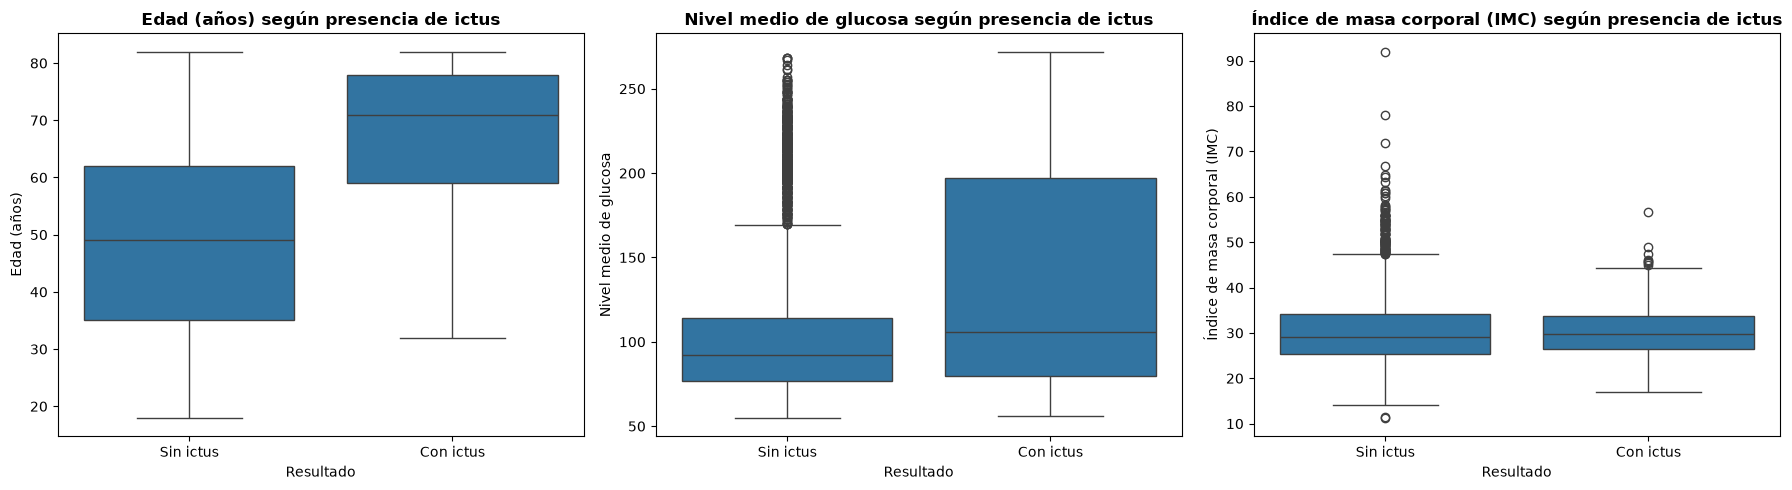

In [47]:
#crea boxplots para ver gráficamente como se relacionan las variables numéricas con la variable objetivo.

nombres_variables = {
    'age': 'Edad (años)',
    'avg_glucose_level': 'Nivel medio de glucosa',
    'bmi': 'Índice de masa corporal (IMC)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (variable, nombre) in zip(axes, nombres_variables.items()):

    sns.boxplot(
        data=df_adultos,
        x='stroke',
        y=variable,
        ax=ax
    )

    ax.set_title(
        f'{nombre} según presencia de ictus',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Resultado')
    ax.set_ylabel(nombre)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sin ictus', 'Con ictus'])

plt.tight_layout()
plt.show()

Los boxplots muestran diferencias claras entre las personas que han sufrido un ictus y las que no. En el caso de la edad, el grupo con ictus presenta una mediana considerablemente superior y una distribución más concentrada en edades avanzadas. Para el nivel medio de glucosa, la mediana también es algo mayor en el grupo con ictus, aunque destaca especialmente su mayor dispersión, lo que indica una variabilidad más elevada entre estos pacientes. En cambio, las distribuciones del IMC son bastante similares en ambos grupos, con medianas próximas y un rango intercuartílico parecido, aunque se observan numerosos valores atípicos, especialmente en el grupo sin ictus. Este último boxplot se ha elaborado únicamente con los valores de IMC disponibles: los valores nulos no se representan ni se han imputado todavía, por lo que las conclusiones sobre esta variable se refieren exclusivamente a los participantes con IMC registrado. 

El gráfico muestra la estimación de densidad de kernel (KDE) del nivel promedio de glucosa en sangre (avg_glucose_level), comparando dos grupos según la ocurrencia de infarto cerebral: Sin Infarto (0) en azul y Con Infarto (1) en naranja.

Ambas curvas presentan dos picos o concentraciones principales de pacientes:

Primer pico (Normoglucemia): Concentrado alrededor de los 75 - 100 mg/dL, donde se sitúa la mayor parte de la población sana.

Segundo pico (Hiperglucemia): Ubicado en valores elevados, aproximadamente entre los 200 y 220 mg/dL.

En el grupo Sin Infarto (azul), la mayoría de los pacientes se concentra en el rango normal (alrededor de 85 mg/dL), cayendo drásticamente en niveles superiores a 140 mg/dL.

En el grupo Con Infarto (naranja), la curva es más ancha y achatada en el primer rango, pero muestra una segunda joroba prominente a partir de los 150 mg/dL (a la derecha de la línea discontinua de corte).

Existe una clara asociación entre niveles elevados de glucosa en sangre (hiperglucemia/diabetes) y el aumento en la probabilidad de sufrir un infarto cerebral. Un nivel de glucosa en el rango alto de 200–220 mg/dL incrementa notablemente la proporción de pacientes en la clase positiva (stroke = 1), convirtiendo a esta variable en un predictor clave para los modelos de Machine Learning.

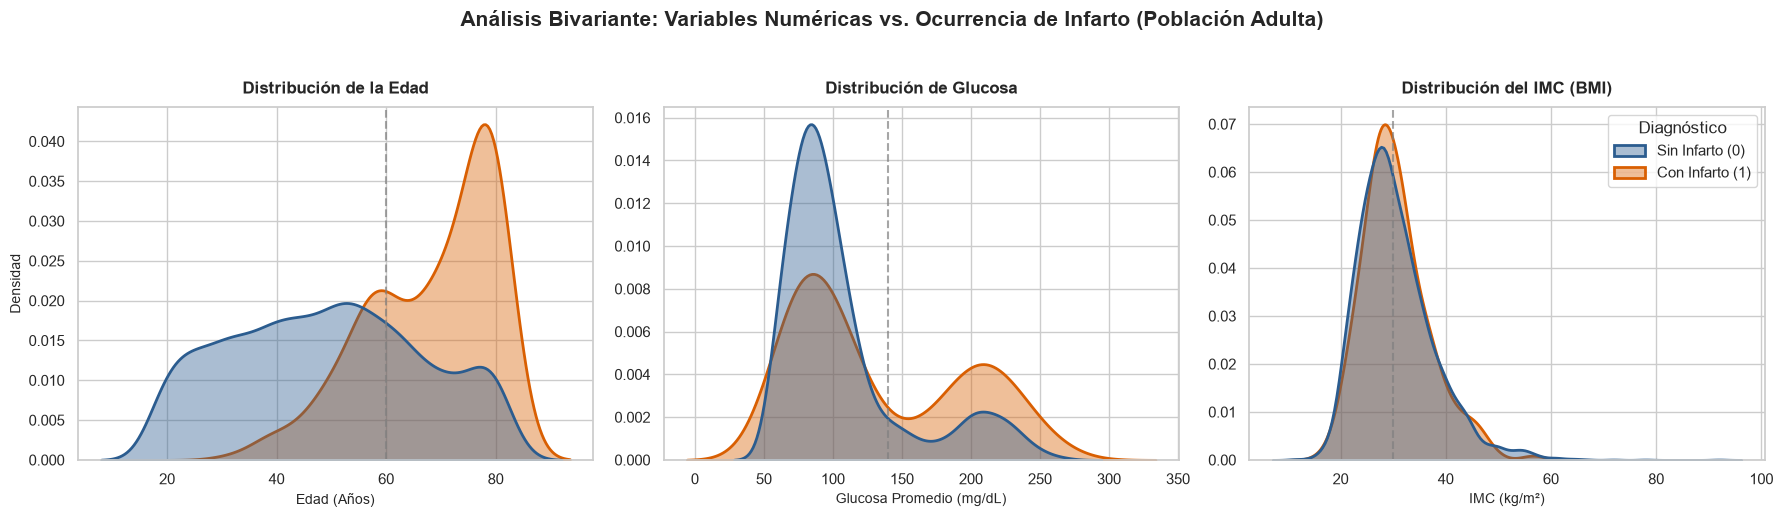

In [ ]:
# gráficos de densidad para age, avg_glucose_level y bmi

sns.set_theme(style="whitegrid")

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definir variables continuas y sus datos clínicos
variables = [
    {
        "col": "age",
        "title": "Distribución de la Edad",
        "xlabel": "Edad (Años)",
        "cut": 60,
        "cut_label": "Corte de Riesgo (60 años)",
    },
    {
        "col": "avg_glucose_level",
        "title": "Distribución de Glucosa",
        "xlabel": "Glucosa Promedio (mg/dL)",
        "cut": 140,
        "cut_label": "Hiperglucemia (140 mg/dL)",
    },
    {
        "col": "bmi",
        "title": "Distribución del IMC (BMI)",
        "xlabel": "IMC (kg/m²)",
        "cut": 30,
        "cut_label": "Umbral Obesidad (30 kg/m²)",
    },
]

# Paleta y etiquetas para la leyenda
colors = {0: "#2b5c8f", 1: "#d95f02"}

# Generar cada subgráfico
for i, var in enumerate(variables):
    ax = axes[i]

    sns.kdeplot(
        data=df_adultos,
        x=var["col"],
        hue="stroke",
        common_norm=False,
        fill=True,
        alpha=0.4,
        palette=colors,
        linewidth=2,
        ax=ax,
        legend=(i == 2),  # Solo mostrar leyenda en el último gráfico
    )

    # Títulos y ejes
    ax.set_title(var["title"], fontsize=12, pad=10, fontweight="bold")
    ax.set_xlabel(var["xlabel"], fontsize=10)
    ax.set_ylabel("Densidad" if i == 0 else "", fontsize=10)

    # Línea de referencia clínica
    ax.axvline(
        x=var["cut"],
        color="gray",
        linestyle="--",
        alpha=0.7,
        label=var["cut_label"],
    )

# Configurar leyenda en el último panel
leg = axes[2].get_legend()
if leg:
    leg.set_title("Diagnóstico")
    new_labels = ["Sin Infarto (0)", "Con Infarto (1)"]
    for t, l in zip(leg.texts, new_labels):
        t.set_text(l)

plt.suptitle(
    "Análisis Bivariante: Variables Numéricas vs. Ocurrencia de Infarto (Población Adulta)",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

Gráficos de densidad:
Distribución de la Edad (age): Es el factor de riesgo determinante. Mientras la población control (sin ictus) se distribuye de forma uniforme entre los 18 y 60 años, la curva de infarto se dispara drásticamente a partir del umbral de los 60 años, concentrando la gran mayoría de casos entre los 70 y 80 años.

Distribución de Glucosa (avg_glucose_level): Revela un patrón bimodal. En sujetos sanos predomina la normoglucemia (< 100 mg/dL). En cambio, el grupo con infarto presenta una joroba secundaria prominente por encima de los 140–150 mg/dL (hiperglucemia/diabetes), confirmando los niveles elevados de glucosa como un fuerte predictor clínico.

Distribución del IMC (bmi): Ambas curvas son prácticamente superponibles, con un pico centrado en el rango de sobrepeso/obesidad ligera (~28–30 kg/m²). El IMC por sí solo no discrimina la ocurrencia de infarto, aunque sigue siendo un factor coadyuvante relevante al interactuar con la edad y la glucosa.

<a id="variables-categoricas"></a>
#### <a id="seccion-1-2-2"></a>Variables categóricas

Estudio de la relación de cada variable categórica respecto a stroke.

In [48]:
#Identificación de variables categóricas

variables_categoricas = [
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]
print("Variables categóricas:", variables_categoricas)

Variables categóricas: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
